# 🏦 Credit Scoring EDA — Loan Management System
### Publication-Quality Exploratory Data Analysis
> **Audience:** Executive / Risk Committee  
> **Purpose:** Portfolio health, NPA profiling, and key risk-driver identification

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")

pandas     : 2.3.3
numpy      : 2.2.6
matplotlib : 3.10.9
seaborn    : 0.13.2


## 1 · Load Dataset

In [10]:
print("Loading Dataset...")
df = pd.read_csv(r"D:\lms_ai_brain\data\lms_advanced_master.csv")

# ── Guarantee 'defaulted' is integer so palette dicts work correctly ──
df['defaulted'] = df['defaulted'].astype(int)

print(f"✅  Loaded — {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Loading Dataset...
✅  Loaded — 8,000 rows × 30 columns


,applicant_age,gender,province,monthly_income_npr,loan_amount_npr,loan_tenure_months,close_year,max_dpd_24m,overdue_count_12m,bounce_count_12m,...,credit_history_months,hard_enquiry_6m,bank_tenure_months,product_count,avg_deposit_12m,bs_month_applied,festival_proximity,district_npa_rate,remittance_inflow_flag,defaulted
0,42,Female,Sudurpashchim,35300,255000,48,2022,0,0,0,...,41,2,3,2,119300.0,7,5,0.0171,0,0
1,27,Male,Madhesh,17800,173000,84,2022,18,3,4,...,5,1,14,2,76500.0,11,29,0.0149,1,1
2,34,Male,Karnali,23300,193000,120,2019,0,0,0,...,55,1,96,2,500.0,5,7,0.0156,1,0


## 2 · Global Design System — Professional Light Theme
All colour tokens, font sizes, and helper utilities are centralised here.
Every chart inherits from this single source of truth.

In [11]:
# ═══════════════════════════════════════════════════════════════
#  LIGHT-THEME DESIGN TOKENS
# ═══════════════════════════════════════════════════════════════

# Canvas & panel
FIG_BG       = "#FFFFFF"   # pure white figure background
PANEL_BG     = "#FAFAFA"   # near-white panel face
GRID_CLR     = "#E5E5E5"   # very light grey gridlines
SPINE_CLR    = "#CCCCCC"   # subtle axis border

# Typography
TEXT_TITLE   = "#1A1A2E"   # near-black navy  – chart titles
TEXT_LABEL   = "#2C2C54"   # deep navy        – axis labels
TEXT_TICK    = "#555577"   # muted navy-grey  – tick labels
TEXT_ANNOT   = "#444466"   # annotation text

# Semantic colours  (corporate-grade, not saturated)
CLR_REPAID   = "#1A7A4A"   # forest green  – healthy / repaid
CLR_DEFAULT  = "#C0392B"   # deep red      – NPA / default
CLR_NAVY     = "#1B4F8A"   # corporate blue – neutral accent
CLR_AMBER    = "#D4820A"   # amber warning reference line

# Gradient for ranked bar (darkest = worst province)
PROV_CMAP    = "RdYlGn_r"  # red (high risk) → green (low risk)

# Typography scale
FONT_SUPTITLE = 16
FONT_TITLE    = 12
FONT_LABEL    = 10
FONT_TICK     =  8
FONT_ANNOT    =  8
FONT_FAMILY   = "DejaVu Sans"

# ── Reset matplotlib to a clean white slate ───────────────────
plt.rcParams.update({
    'font.family'        : FONT_FAMILY,
    'figure.facecolor'   : FIG_BG,
    'axes.facecolor'     : PANEL_BG,
    'axes.edgecolor'     : SPINE_CLR,
    'axes.labelcolor'    : TEXT_LABEL,
    'axes.titlecolor'    : TEXT_TITLE,
    'xtick.color'        : TEXT_TICK,
    'ytick.color'        : TEXT_TICK,
    'text.color'         : TEXT_TITLE,
    'grid.color'         : GRID_CLR,
    'grid.linewidth'     : 0.6,
    'grid.linestyle'     : '--',
    'axes.grid'          : False,   # each chart controls its own grid
    'legend.framealpha'  : 0.9,
    'legend.edgecolor'   : SPINE_CLR,
})

# ── Helper: apply consistent light theme to one Axes ──────────
def style_ax(ax, title=None, xlabel=None, ylabel=None,
             grid_axis='y', xtick_rot=0):
    """Despine, add muted dashed grid, set text styles."""
    ax.set_facecolor(PANEL_BG)

    # Despine top + right
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(SPINE_CLR)
    ax.spines['bottom'].set_color(SPINE_CLR)

    # Grid
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID_CLR, linewidth=0.6,
                linestyle='--', alpha=1.0, zorder=0)
    ax.set_axisbelow(True)

    # Tick params
    ax.tick_params(axis='both', labelsize=FONT_TICK,
                   colors=TEXT_TICK, length=3, width=0.6)
    if xtick_rot:
        ax.tick_params(axis='x', rotation=xtick_rot)

    # Labels & title
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=FONT_LABEL,
                      color=TEXT_LABEL, labelpad=7)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=FONT_LABEL,
                      color=TEXT_LABEL, labelpad=7)
    if title:
        ax.set_title(title, fontsize=FONT_TITLE,
                     color=TEXT_TITLE, fontweight='bold',
                     pad=12, loc='left')


print("✅  Light design system ready.")

✅  Light design system ready.


## 3 · Publication-Quality Visual Dashboard

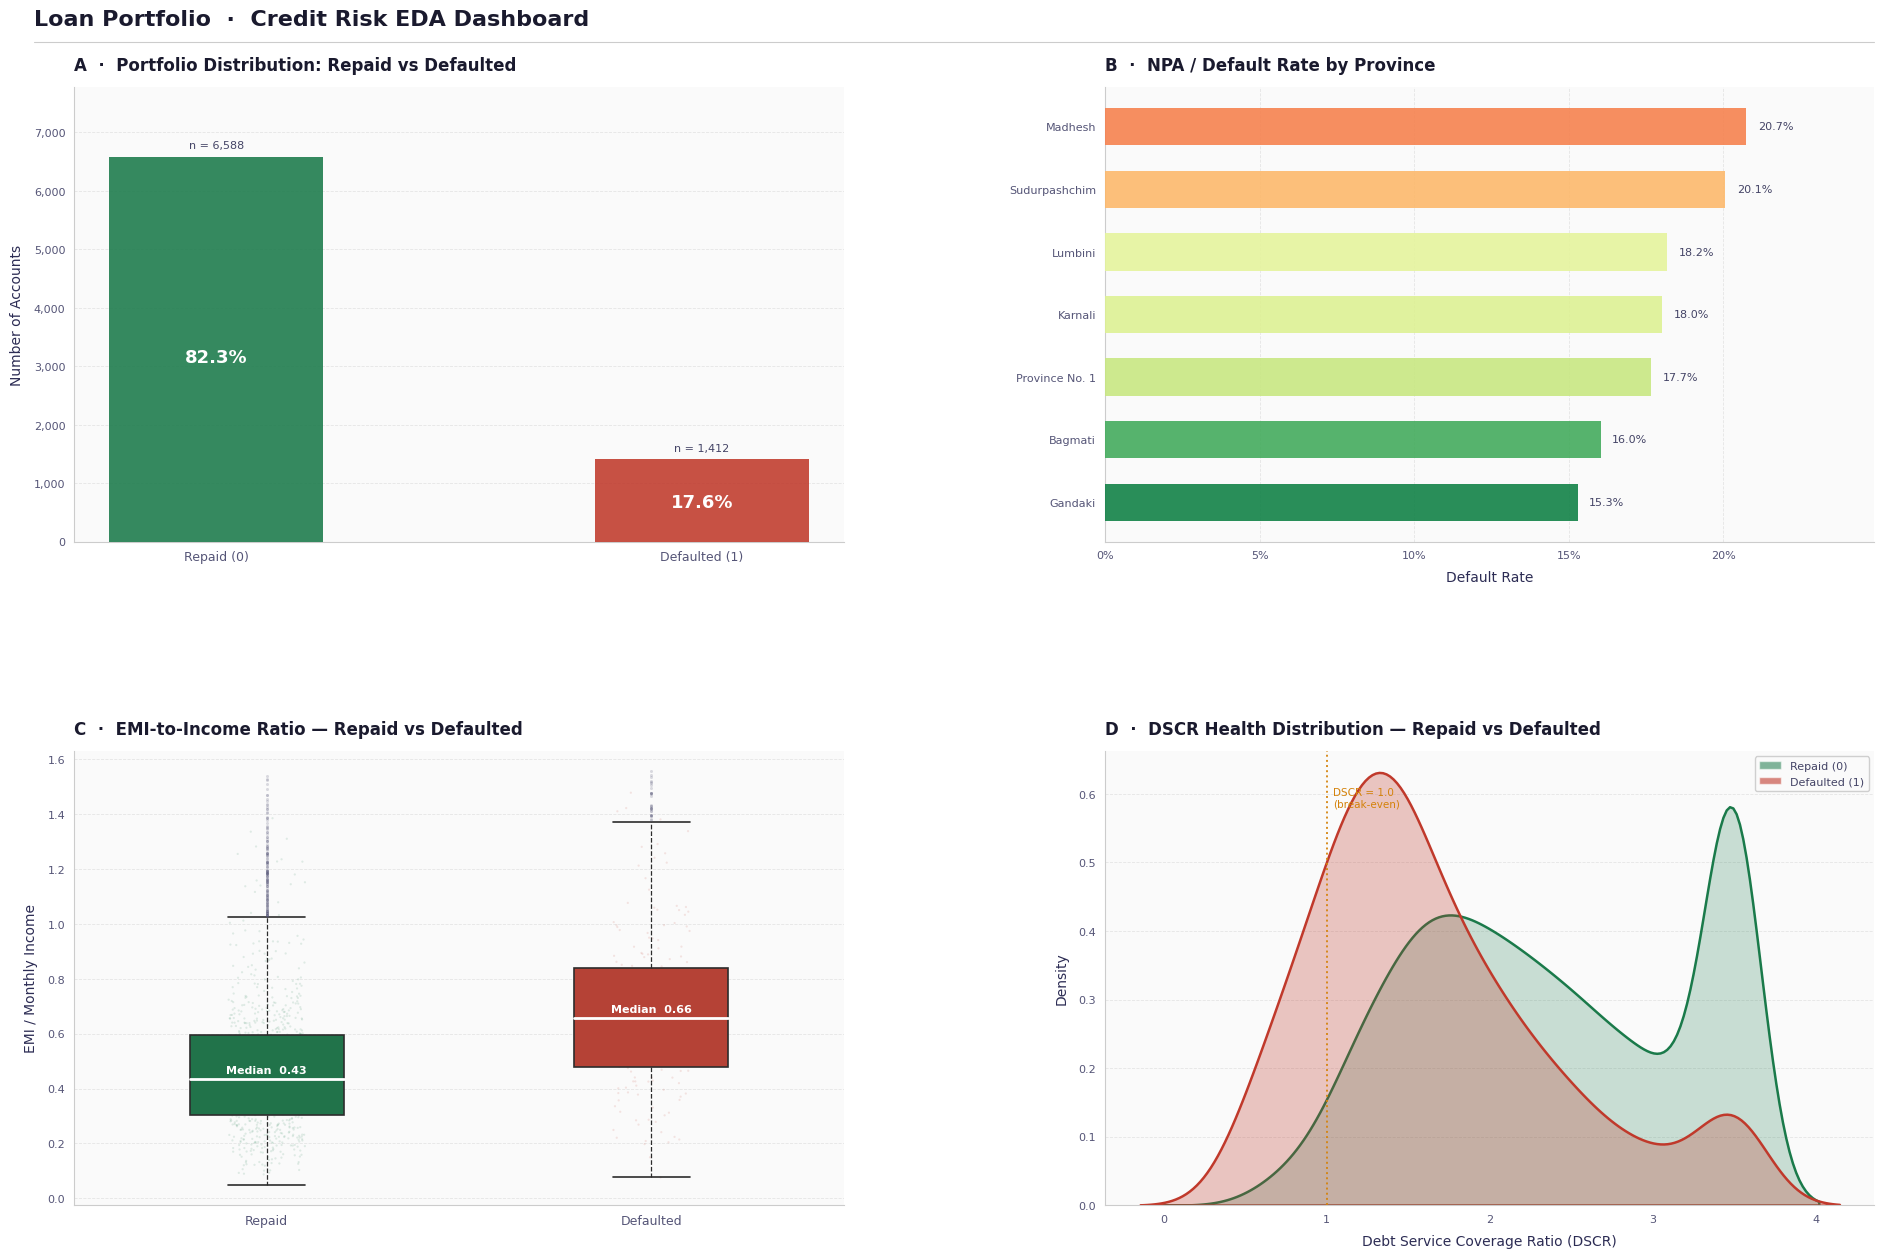

✅  Visual charts saved → D:\lms_ai_brain\data\eda_visuals.png


In [12]:
# ═══════════════════════════════════════════════════════════════
#  SECTION 1 — GENERATE VISUAL CHARTS  (fully upgraded)
# ═══════════════════════════════════════════════════════════════

# ── Pre-compute aggregates ────────────────────────────────────
prov_default = (
    df.groupby('province')['defaulted']
      .mean()
      .sort_values(ascending=False)
)

# Suppress extreme outliers (99th pct cap)
emi_cap  = df['emi_income_ratio'].quantile(0.99)
df_emi   = df[df['emi_income_ratio'] <= emi_cap].copy()
df_emi['defaulted'] = df_emi['defaulted'].astype(int)

dscr_cap = df['dscr'].quantile(0.99)
df_dscr  = df[df['dscr'] <= dscr_cap].copy()
df_dscr['defaulted'] = df_dscr['defaulted'].astype(int)

# Explicit string labels for boxplot / stripplot x-axis
LABEL_MAP   = {0: 'Repaid', 1: 'Defaulted'}
df_emi['Status']  = df_emi['defaulted'].map(LABEL_MAP)
df_dscr['Status'] = df_dscr['defaulted'].map(LABEL_MAP)
STATUS_PAL  = {'Repaid': CLR_REPAID, 'Defaulted': CLR_DEFAULT}


# ── Figure layout ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13), facecolor=FIG_BG)
fig.suptitle(
    "Loan Portfolio  ·  Credit Risk EDA Dashboard",
    x=0.05, ha='left',
    fontsize=FONT_SUPTITLE, fontweight='bold',
    color=TEXT_TITLE, y=0.99
)
# Thin decorative rule below suptitle
fig.add_artist(
    plt.Line2D([0.05, 0.97], [0.965, 0.965],
               transform=fig.transFigure,
               color=SPINE_CLR, linewidth=0.8)
)

gs = GridSpec(
    2, 2, figure=fig,
    hspace=0.46, wspace=0.34,
    left=0.07, right=0.97,
    top=0.93, bottom=0.07
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])


# ─────────────────────────────────────────────────────────────
#  CHART A  ·  Portfolio Distribution: Repaid vs Defaulted
# ─────────────────────────────────────────────────────────────
counts  = df['defaulted'].value_counts().sort_index()
labels  = ['Repaid (0)', 'Defaulted (1)']
palette = [CLR_REPAID, CLR_DEFAULT]
total   = counts.sum()

bars_a = ax_a.bar(
    labels, counts.values,
    color=palette, width=0.44,
    zorder=3, linewidth=0,
    alpha=0.88
)

# Dual annotation: bold % inside bar + grey count above bar
for bar, count in zip(bars_a, counts.values):
    pct = count / total
    # Percentage — white, centred inside bar
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.48,
        f"{pct:.1%}",
        ha='center', va='center',
        fontsize=13, fontweight='bold',
        color='white', zorder=4
    )
    # Count — dark, floating above bar
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.016,
        f"n = {count:,}",
        ha='center', va='bottom',
        fontsize=FONT_ANNOT, color=TEXT_ANNOT, zorder=4
    )

style_ax(ax_a,
         title="A  ·  Portfolio Distribution: Repaid vs Defaulted",
         ylabel="Number of Accounts",
         grid_axis='y')
ax_a.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_a.set_ylim(0, counts.max() * 1.18)
ax_a.tick_params(axis='x', labelsize=FONT_TICK + 1)


# ─────────────────────────────────────────────────────────────
#  CHART B  ·  NPA / Default Rate by Province
# ─────────────────────────────────────────────────────────────
n_prov   = len(prov_default)
# Continuous red-to-green map: most dangerous = deepest red
norm_vals = (prov_default.values - prov_default.min()) / \
            (prov_default.max() - prov_default.min() + 1e-9)
bar_clrs_b = plt.cm.RdYlGn_r(norm_vals * 0.72 + 0.05)

bars_b = ax_b.barh(
    prov_default.index,
    prov_default.values,
    color=bar_clrs_b,
    height=0.60,
    zorder=3, linewidth=0,
    alpha=0.88
)

x_max = prov_default.max()
for bar, val in zip(bars_b, prov_default.values):
    ax_b.text(
        val + x_max * 0.018,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}",
        va='center', ha='left',
        fontsize=FONT_ANNOT, color=TEXT_ANNOT
    )

style_ax(ax_b,
         title="B  ·  NPA / Default Rate by Province",
         xlabel="Default Rate",
         grid_axis='x')
ax_b.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0))
ax_b.set_xlim(0, x_max * 1.20)
ax_b.invert_yaxis()  # worst province at top


# ─────────────────────────────────────────────────────────────
#  CHART C  ·  EMI-to-Income Ratio Impact (Boxplot)
# ─────────────────────────────────────────────────────────────
# Use string 'Status' column → palette keys are plain strings → no type mismatch
sns.boxplot(
    data=df_emi,
    x='Status', y='emi_income_ratio',
    order=['Repaid', 'Defaulted'],
    palette=STATUS_PAL,
    width=0.40,
    linewidth=1.2,
    fliersize=2.0,
    flierprops=dict(marker='o', alpha=0.20, markersize=2.2,
                    markerfacecolor=TEXT_TICK, markeredgewidth=0),
    medianprops=dict(color='white', linewidth=2.0, solid_capstyle='round'),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=0.9, linestyle='--'),
    capprops=dict(linewidth=1.2),
    ax=ax_c,
    zorder=3,
    saturation=0.85
)

# Transparent strip overlay (1 000-point sample)
sns.stripplot(
    data=df_emi.sample(min(1000, len(df_emi)), random_state=42),
    x='Status', y='emi_income_ratio',
    order=['Repaid', 'Defaulted'],
    palette=STATUS_PAL,
    size=1.6, alpha=0.12, jitter=True,
    ax=ax_c, zorder=2
)

style_ax(ax_c,
         title="C  ·  EMI-to-Income Ratio — Repaid vs Defaulted",
         ylabel="EMI / Monthly Income",
         grid_axis='y')
ax_c.set_xlabel('')
ax_c.tick_params(axis='x', labelsize=FONT_TICK + 1)

# Median callout labels
for i, grp_label in enumerate(['Repaid', 'Defaulted']):
    grp_int = 0 if grp_label == 'Repaid' else 1
    med = df_emi[df_emi['defaulted'] == grp_int]['emi_income_ratio'].median()
    ax_c.text(
        i, med + 0.014,
        f"Median  {med:.2f}",
        ha='center', va='bottom',
        fontsize=FONT_ANNOT, color='white',
        fontweight='bold', zorder=5
    )


# ─────────────────────────────────────────────────────────────
#  CHART D  ·  DSCR Distribution (KDE)
# ─────────────────────────────────────────────────────────────
sns.kdeplot(
    data=df_dscr[df_dscr['defaulted'] == 0],
    x='dscr', fill=True,
    color=CLR_REPAID, alpha=0.22,
    linewidth=1.8, bw_adjust=1.2,
    label='Repaid (0)', ax=ax_d
)
sns.kdeplot(
    data=df_dscr[df_dscr['defaulted'] == 1],
    x='dscr', fill=True,
    color=CLR_DEFAULT, alpha=0.28,
    linewidth=1.8, bw_adjust=1.2,
    label='Defaulted (1)', ax=ax_d
)

# Break-even reference line (DSCR = 1.0)
ax_d.axvline(x=1.0, color=CLR_AMBER, linewidth=1.4,
             linestyle=':', alpha=0.90, zorder=4)

style_ax(ax_d,
         title="D  ·  DSCR Health Distribution — Repaid vs Defaulted",
         xlabel="Debt Service Coverage Ratio (DSCR)",
         ylabel="Density",
         grid_axis='y')

# Add reference label AFTER style_ax sets ylim
y_top = ax_d.get_ylim()[1]
ax_d.text(1.04, y_top * 0.92, "DSCR = 1.0\n(break-even)",
          color=CLR_AMBER, fontsize=FONT_ANNOT - 0.5, va='top')

ax_d.legend(
    handles=[
        mpatches.Patch(facecolor=CLR_REPAID,  alpha=0.55, label='Repaid (0)'),
        mpatches.Patch(facecolor=CLR_DEFAULT, alpha=0.60, label='Defaulted (1)'),
    ],
    fontsize=FONT_ANNOT, framealpha=0.92,
    edgecolor=SPINE_CLR, labelcolor=TEXT_ANNOT
)


# ── Save ─────────────────────────────────────────────────────
out_path = r"D:\lms_ai_brain\data\eda_visuals.png"
plt.savefig(out_path, dpi=180, facecolor=FIG_BG, bbox_inches='tight')
plt.show()
print(f"✅  Visual charts saved → {out_path}")

## 4 · Text Report for Documentation

In [13]:
# ═══════════════════════════════════════════════════════════════
#  SECTION 2 — PRINT TEXT REPORT  (kept exactly as original)
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("📊 EDA TEXT REPORT FOR DOCUMENTATION")
print("="*50)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\n--- Missing Values Check ---")
nulls = df.isnull().sum().sum()
print(f"Total Null/Missing Values: {nulls}")

print("\n--- Target Variable Balance (defaulted) ---")
print(df['defaulted'].value_counts(normalize=True).round(4) * 100)

print("\n--- Temporal Distribution (close_year) ---")
print(df['close_year'].value_counts().sort_index())

print("\n--- Top 5 Features Correlated with Default (Risk) ---")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['defaulted'].sort_values(ascending=False)
print(correlations.drop('defaulted').head(5).round(4))

print("\n--- Top 5 Features Negatively Correlated (Protective) ---")
print(correlations.tail(5).round(4))
print("="*50)


📊 EDA TEXT REPORT FOR DOCUMENTATION
Dataset Shape: 8000 rows, 30 columns

--- Missing Values Check ---
Total Null/Missing Values: 0

--- Target Variable Balance (defaulted) ---
defaulted
0    82.35
1    17.65
Name: proportion, dtype: float64

--- Temporal Distribution (close_year) ---
close_year
2018     779
2019     745
2020    1240
2021    1201
2022    1677
2023    1373
2024     985
Name: count, dtype: int64

--- Top 5 Features Correlated with Default (Risk) ---
emi_income_ratio     0.3497
max_dpd_24m          0.2714
active_loan_count    0.2168
overdue_count_12m    0.2012
bounce_count_12m     0.1828
Name: defaulted, dtype: float64

--- Top 5 Features Negatively Correlated (Protective) ---
insurance_flag       -0.0605
collateral_score     -0.0889
income_stability     -0.0990
loan_tenure_months   -0.1566
dscr                 -0.3142
Name: defaulted, dtype: float64
